In [1]:
import sys
sys.path.append('../src')

from IPython.display import display, clear_output
from PIL import Image, ImageOps, ImageDraw, ImageFont, ImageChops
import matplotlib.pyplot as plt
import numpy as np

from palette.symbol2value import get_asciis, symbols_sorted
from image.processing import preprocess_img
from rendering.image import render_symbols_img
from converters.line_heuristics.utils import evaluate_symbol_arr

In [2]:
FONT = ImageFont.truetype("../fonts/OpenSans-Regular.ttf", 18)
# FONT = ImageFont.truetype("../fonts/CascadiaMono.ttf", 18)

CHAR_SET = symbols_sorted(get_asciis(), FONT)[::2]
print(CHAR_SET)
print(len(CHAR_SET))

IMG_PATH = "../imgs/irad_grad.bmp"

[' ', '`', ',', ':', ';', '"', 'i', '+', '<', '>', '^', 'r', '?', 't', ')', 'c', 'f', 'J', '{', '7', 'v', ']', 'T', 'F', 'o', 'C', 'a', 'y', '5', 'S', '4', 'X', '6', 'P', '9', 'U', 'b', 'p', '$', 'H', 'G', 'O', 'w', 'g', 'N', '&', '@', 'W']
48


(512, 512)
(102, 102)


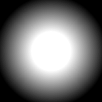

In [3]:
orig_img = Image.open(IMG_PATH).convert("L")
print(orig_img.size)
prep_img = preprocess_img(orig_img, 0.2, contrast=2.0)
print(prep_img.size)
display(prep_img)

[[' ', ' ', ' ', ' ', ' ', 'g', 'g', 'g', 'g', 'g', ',', ' ', ' ', ' ', ' ', ' '], [' ', '@', '@', '@', '@', '@', 'J', ',', ' ', ' '], [' ', 'W', 'W', '@', '@', '@', 'J', ' ', ' '], [' ', ' ', ' ', ' ', '"', 'W', 'W', '$', '"', '"', ' ', ' ', ' ', ' ']]
-16418.824394463667


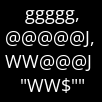

In [4]:
from converters.line_heuristics.greedy import GreedyLineSearch

res_arr = GreedyLineSearch(CHAR_SET, FONT).process_image(prep_img)
print(res_arr)
print(evaluate_symbol_arr(prep_img, res_arr, FONT, prep_img.size))
display(render_symbols_img(res_arr, FONT, wh=prep_img.size))

0 -9255.054738562092
1 -8729.625816993464
2 -8601.685866013071
6 -8529.08251633987
8 -7923.138888888889
15 -6797.10089869281
0 -26019.631535947712
17 -26001.198529411766
47 -25556.013480392157
199 -25488.58088235294
0 -30285.917075163397
11 -30017.544934640522
19 -29918.321895424837
23 -29680.832107843136
208 -29663.38316993464
0 -13932.248366013071
1 -13235.290032679739
14 -13018.599264705883
35 -12683.990604575163
110 -12623.468954248367
239 -12598.107843137255
294 -12476.98202614379
[[' ', ' ', ';', ',', '^', '`', 'a', 'J', '&', '@', 'r', 'v'], ['a', 'a', 'J', 'W', 'J', 'c', ']', 't', '6', '$', ':'], ['U', 'f', 'P', 'f', '5', ']', '{', '$', 'P', 'N'], ['`', ':', 'T', 'b', 'C', 'i', 'f', '`', '9', 't', 'S', '>', '`']]
-17566.22433679354


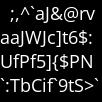

In [5]:
from converters.line_heuristics.random_search import RandomLineSearch

res_arr = RandomLineSearch(CHAR_SET, FONT, 300).process_image(prep_img)
print(res_arr)
print(evaluate_symbol_arr(prep_img, res_arr, FONT, prep_img.size))
display(render_symbols_img(res_arr, FONT, wh=prep_img.size))

-1 -7436.255310457516
1 -6963.812908496732
12 -6604.4607843137255
99 -6500.455882352941
133 -6395.310866013072
140 -6310.943627450981
-1 -26311.14093137255
0 -25895.270833333332
1 -25787.613970588234
2 -25674.073937908495
3 -25517.257761437908
4 -24902.33660130719
10 -24648.70016339869
11 -24573.807598039217
17 -24191.543300653593
19 -24136.339869281044
35 -24068.72181372549
54 -24058.668709150326
56 -24031.071486928104
65 -23910.241421568626
66 -23855.571486928104
73 -23657.70751633987
101 -23622.50204248366
106 -23389.296977124184
197 -23365.736928104576
-1 -30176.412990196077
1 -29586.118464052288
2 -29576.11683006536
4 -29480.395833333332
6 -29338.493055555555
8 -29154.495506535946
13 -28954.45424836601
21 -28912.20016339869
34 -28794.80433006536
46 -28445.117647058825
65 -28336.9272875817
83 -28164.16911764706
85 -28091.35661764706
127 -28086.825571895424
-1 -13261.531045751633
0 -12807.271650326797
2 -12164.379901960785
23 -11929.66135620915
46 -11763.310866013071
112 -11757.8884

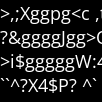

In [6]:
from converters.line_heuristics.harmony_search import HarmonyLineSearch

res_arr = HarmonyLineSearch(CHAR_SET, FONT, generations=200, pop_count=20, mem_rate=0.6, pa_rate=0.2, pa=len(CHAR_SET) // 4).process_image(prep_img)
print(evaluate_symbol_arr(prep_img, res_arr, FONT, prep_img.size))
print(res_arr)
display(render_symbols_img(res_arr, FONT, wh=prep_img.size))


2 -7725.843954248366
4 -7529.848856209151
5 -7461.966503267974
7 -7287.651552287582
9 -7252.060866013072
10 -7199.278594771242
12 -6869.530637254902
15 -6750.830882352941
18 -6634.343954248366
20 -6571.512254901961
23 -6515.073937908497
25 -6500.097222222223
26 -6386.092320261438
31 -6371.588235294118
35 -6324.426062091503
40 -6315.056372549019
41 -6315.040032679739
46 -6309.343545751634
50 -6302.362745098039
53 -6273.216911764706
91 -6272.18545751634
1 -25555.271241830065
3 -25225.330473856207
5 -24914.34885620915
6 -24603.131535947712
7 -24451.844362745098
13 -24443.5216503268
15 -24304.287173202614
19 -24211.219362745098
22 -24054.706290849674
26 -24027.595588235294
28 -23933.271241830065
30 -23878.714869281044
32 -23841.80637254902
34 -23838.474673202614
38 -23816.07066993464
40 -23780.837418300653
45 -23760.520833333332
48 -23753.808006535946
50 -23713.178513071896
55 -23671.374183006537
57 -23652.25612745098
0 -29604.187091503267
4 -29489.412173202614
5 -29450.432598039217
6 -291

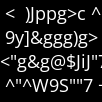

In [7]:
from converters.line_heuristics.genetic_search import GeneticLineSearch

res_arr = GeneticLineSearch(CHAR_SET, FONT, generations=300, pop_count=50).process_image(prep_img)
print(evaluate_symbol_arr(prep_img, res_arr, FONT, prep_img.size))
display(render_symbols_img(res_arr, FONT, wh=prep_img.size))

-1 -7893.9334150326795
5 -7791.533905228758
7 -7738.706290849673
7 -7706.301062091503
8 -7658.821078431372
10 -7643.18954248366
10 -7630.428513071895
10 -7593.770833333333
18 -7585.634395424837
18 -7555.401960784314
18 -7515.16339869281
20 -7334.579248366013
20 -7316.167075163398
34 -7265.173611111111
36 -7263.720996732026
37 -7144.161764705882
37 -7115.351307189542
48 -7101.007761437909
49 -7072.442401960784
52 -7056.674428104575
53 -7028.876225490196
54 -7010.03431372549
56 -6969.34477124183
63 -6891.613970588235
64 -6846.985702614379
65 -6646.071895424837
72 -6635.586192810458
75 -6632.236111111111
81 -6600.421977124183
81 -6564.005310457516
89 -6533.489379084967
91 -6526.740604575163
96 -6525.35089869281
112 -6499.394199346405
114 -6497.484068627451
117 -6471.527369281046
118 -6407.221405228758
118 -6379.354575163398
139 -6236.006535947712
145 -6204.720996732026
146 -6167.3357843137255
149 -6081.25204248366
153 -5836.539624183007
156 -5802.005310457516
158 -5669.402369281046
164 -5

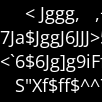

In [8]:
from converters.line_heuristics.pso_search import ParticleSwarmLineSearch

res_arr = ParticleSwarmLineSearch(CHAR_SET, FONT, generations=300, pop_count=50, innertion=0.3, cog_coeff=0.9, soc_coeff=1.2).process_image(prep_img)
print(res_arr)
print(evaluate_symbol_arr(prep_img, res_arr, FONT, prep_img.size))
display(render_symbols_img(res_arr, FONT, wh=prep_img.size))